In [31]:
import pandas as pd
import numpy as np
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

data = pd.read_csv('../data/sp500_features.csv', index_col=0, parse_dates=True)
data.head()

,Close,High,Low,Open,Volume,log_return,realized_volatility_5,realized_volatility_18,realized_volatility_21,return_lag_1,return_lag_2,return_lag_3,return_lag_5,volume_change,volume_ma_5,day_of_week,month,future_volatility_21
Date,,,,,,,,,,,,,,,,,,
2015-02-03,2050.030029,2050.300049,2022.709961,2022.709961,4615900000,0.014336,0.224067,0.173837,0.180978,0.012879,-0.013077,0.009490,-0.013478,0.151577,4.277510e+09,1,2,0.078070
2015-02-04,2041.510010,2054.739990,2036.719971,2048.860107,4141920000,-0.004165,0.190170,0.160776,0.169203,0.014336,0.012879,-0.013077,-0.013588,-0.102684,4.292388e+09,2,2,0.093172
2015-02-05,2062.520020,2063.550049,2043.449951,2043.449951,3821990000,0.010239,0.191629,0.162386,0.168782,-0.004165,0.014336,0.012879,0.009490,-0.077242,4.231358e+09,3,2,0.087412
2015-02-06,2055.469971,2072.399902,2049.969971,2062.280029,4232970000,-0.003424,0.143511,0.159621,0.165366,0.010239,-0.004165,0.014336,-0.013077,0.107530,4.164222e+09,4,2,0.105841
2015-02-09,2046.739990,2056.159912,2041.880005,2053.469971,3549540000,-0.004256,0.143120,0.160259,0.153966,-0.003424,0.010239,-0.004165,0.012879,-0.161454,4.072464e+09,0,2,0.105036


In [32]:
returns = data['log_return'] * 100

split_idx = int(len(data) * 0.8)
train_returns = returns.iloc[:split_idx]
test_returns = returns.iloc[split_idx:]

print(f"Train: {len(train_returns)}, Test: {len(test_returns)}")

Train: 2179, Test: 545


In [33]:
# GARCH model
garch = arch_model(train_returns, vol='GARCH', p=1, q=1, dist='t')
garch_fit = garch.fit(disp='off')
print(garch_fit.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2752.01
Distribution:      Standardized Student's t   AIC:                           5514.02
Method:                  Maximum Likelihood   BIC:                           5542.45
                                              No. Observations:                 2179
Date:                      Sun, Jul 05 2026   Df Residuals:                     2178
Time:                              10:37:11   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

In [34]:
forecasts = garch_fit.forecast(horizon=21, start=train_returns.index[-1])

In [35]:
garch_predictions = []

for i in range(split_idx, len(returns) - 21):
    train_window = returns.iloc[:i]
    model = arch_model(train_window, vol='GARCH', p=1, q=1, dist='t')
    model_fit = model.fit(disp='off')
    model_forecast = model_fit.forecast(horizon=21)
    variance_forecast = model_forecast.variance.values[-1, :].mean()
    volatility_forecast = np.sqrt(variance_forecast * 252) / 100
    garch_predictions.append(volatility_forecast)

print(f"Generated {len(garch_predictions)} GARCH forecasts")

Generated 524 GARCH forecasts


In [36]:
y_test_garch = data['future_volatility_21'].iloc[split_idx:split_idx+len(garch_predictions)]

garch_rmse = np.sqrt(mean_squared_error(y_test_garch, garch_predictions))
garch_mae = mean_absolute_error(y_test_garch, garch_predictions)
garch_r2 = r2_score(y_test_garch, garch_predictions)

print(f"GARCH - RMSE: {garch_rmse:.4f}, MAE: {garch_mae:.4f}, R2: {garch_r2:.4f}")

GARCH - RMSE: 0.0909, MAE: 0.0599, R2: -0.3590


In [37]:
final_results = pd.DataFrame({
    'Model': ['Naive Baseline', 'Linear Regression', 'Random Forest', 'XGBoost', 'GARCH(p=1,q=1)'],
    'RMSE': [0.0906, 0.0730, 0.0915, 0.0951, garch_rmse],
    'MAE': [0.0568, 0.0501, 0.0517, 0.0544, garch_mae],
    'R2': [np.nan, 0.0924, -0.4236, -0.5397, garch_r2]
})
print(final_results.sort_values('RMSE'))

               Model      RMSE       MAE        R2
1  Linear Regression  0.073000  0.050100  0.092400
0     Naive Baseline  0.090600  0.056800       NaN
4     GARCH(p=1,q=1)  0.090897  0.059932 -0.358974
2      Random Forest  0.091500  0.051700 -0.423600
3            XGBoost  0.095100  0.054400 -0.539700


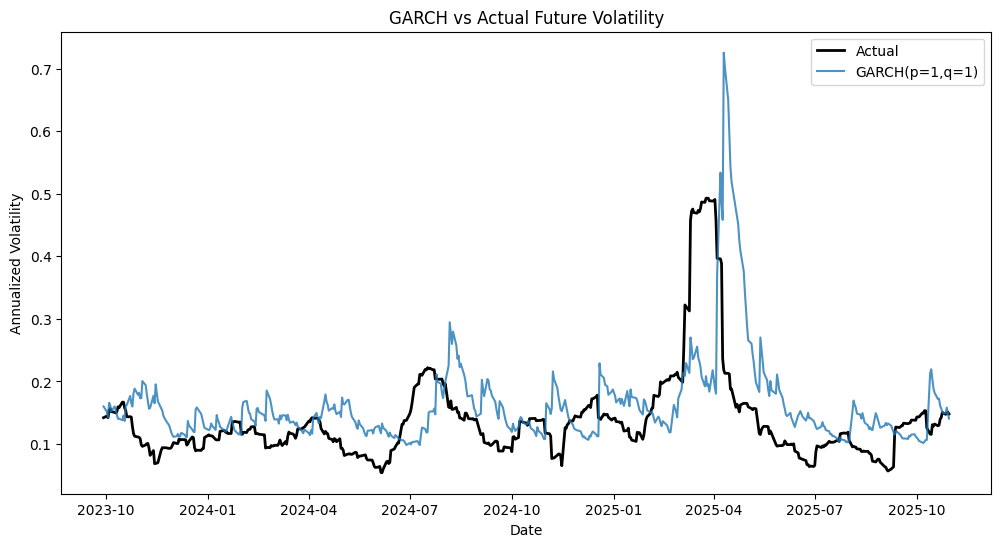

In [38]:
plt.figure(figsize=(12,6))
plt.plot(y_test_garch.index, y_test_garch.values, label='Actual', linewidth=2, color='black')
plt.plot(y_test_garch.index, garch_predictions, label='GARCH(p=1,q=1)', alpha=0.8)
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.title('GARCH vs Actual Future Volatility')
plt.legend()
plt.show()

## Summary

Fitted a GARCH(1,1) model with Student's t-distributed innovations (chosen given the
non-normality confirmed in 01_data_and_stationarity) and generated a rolling 21-day-ahead volatility forecast
across the test period (524 forecasts, refitting the model at each step).

**GARCH(1,1) parameters (full training sample):**

| Parameter | Coefficient | p-value |
|---|---|---|
| ω (omega) | 0.0187 | 0.0016 |
| α (alpha) | 0.1771 | < 0.001 |
| β (beta) | 0.8229 | < 0.001 |
| ν (nu, t-dist df) | 5.61 | < 0.001 |

The high β (0.82) confirms strong volatility persistence — consistent with the volatility
clustering detected via Ljung-Box in 01_data_and_stationarity. The low degrees of freedom (ν ≈ 5.6) for the
Student's t-distribution confirms fat tails in the innovations.

### Final model comparison

| Model | RMSE | MAE | R² |
|---|---|---|---|
| Linear Regression | 0.0730 | 0.0501 | 0.0924 |
| Naive Baseline | 0.0906 | 0.0568 | — |
| GARCH(1,1) | 0.0909 | 0.0599 | -0.3590 |
| Random Forest | 0.0915 | 0.0517 | -0.4236 |
| XGBoost | 0.0951 | 0.0544 | -0.5397 |

**Key finding:** Linear Regression remains the best-performing model overall, even outperforming
GARCH(1,1) — a purpose-built, industry-standard econometric volatility model. GARCH essentially
ties with the naive baseline on RMSE and, like the tree-based models, shows negative R² on this
test period, again pointing to a regime shift between training and test periods rather than a
flaw specific to any one modeling approach.

**Overall conclusion (04_baseline_model - 06_garch_comparison):** Across five models spanning classical econometrics (GARCH),
linear statistics, and machine learning (Random Forest, XGBoost), the simplest model — linear
regression on a handful of engineered volatility and volume features — generalizes best to
unseen data. This reinforces a central theme of this project: added model complexity does not
guarantee better forecasts in financial time series, where structural regime changes can
undermine even well-established, purpose-built models like GARCH.